# Normality Tests and Diagnostics in R

## Overview

Testing for normality is a prerequisite check before applying parametric tests that assume normally distributed data or residuals. Visual inspection (Q-Q plots, histograms) is always the primary tool — formal tests are supplementary.

| Test | Statistic | Best for | Limitation |
|---|---|---|---|
| **Shapiro-Wilk** | W | General purpose; small to medium n (n ≤ 2000) | Very sensitive at large n — trivially rejects normality |
| **Kolmogorov-Smirnov** (Lilliefors) | D | Larger samples | Lower power than Shapiro-Wilk; requires estimated parameters |
| **Anderson-Darling** | A² | More sensitive to tail deviations than K-S | Also over-rejects at large n |
| **Q-Q plot** | Visual | All situations — primary diagnostic | Subjective |
| **Histogram** | Visual | Understanding distribution shape | Depends on bin width |

> **Critical advice:**  
> Formal normality tests should not be used to decide whether to use a parametric test. With small n they have low power and miss real non-normality; with large n they reject trivial deviations that have no practical impact. **Visual assessment of Q-Q plots is the primary tool.** Use formal tests only to quantify what you already see visually.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(nortest)     # ad.test(), lillie.test()
library(patchwork)

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'patchwork' was built under R version 4.4.3"


## Reference Distributions

We simulate five distributions to illustrate how tests and plots behave across a range of shapes.

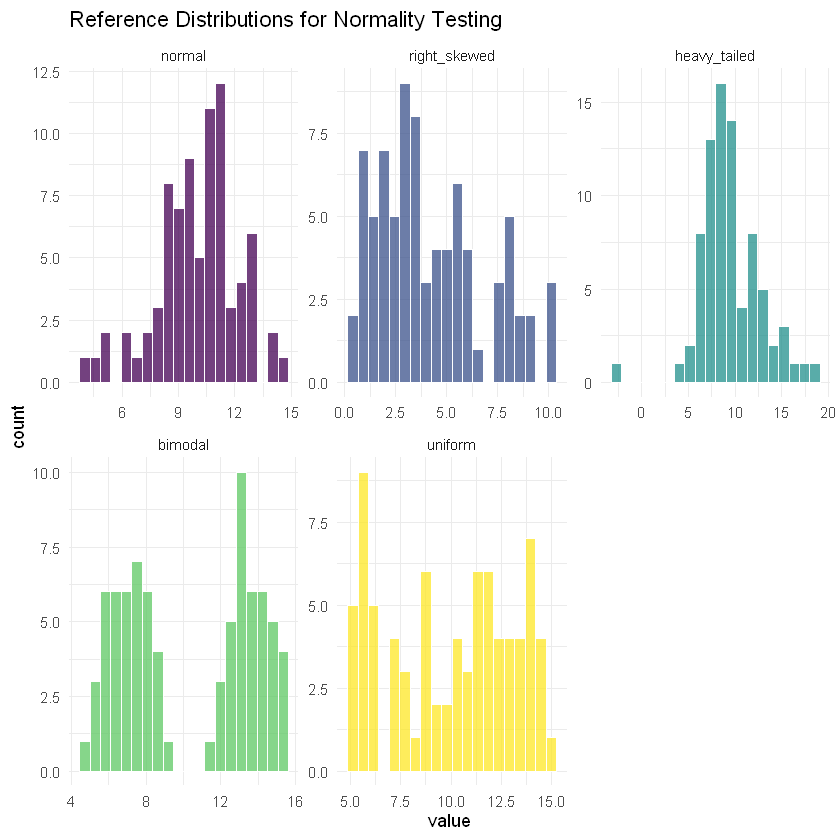

In [2]:
n <- 80

distributions <- list(
  normal       = rnorm(n, 10, 2),
  right_skewed = rgamma(n, shape = 2, rate = 0.5),
  heavy_tailed = rt(n, df = 3) * 2 + 10,
  bimodal      = c(rnorm(n/2, 7, 1), rnorm(n/2, 14, 1)),
  uniform      = runif(n, 5, 15)
)

dist_df <- map_dfr(names(distributions), function(nm) {
  tibble(distribution = nm, value = distributions[[nm]])
}) %>%
  mutate(distribution = factor(distribution,
                                levels = names(distributions)))

# ── Histogram overview ────────────────────────────────────────────────────────
ggplot(dist_df, aes(x = value, fill = distribution)) +
  geom_histogram(bins = 20, alpha = 0.75, color = "white") +
  facet_wrap(~ distribution, scales = "free", ncol = 3) +
  scale_fill_viridis_d() +
  labs(title = "Reference Distributions for Normality Testing") +
  theme_minimal() + theme(legend.position = "none")

---

## Q-Q Plots: The Primary Diagnostic

A Q-Q (quantile-quantile) plot compares the sample quantiles against the theoretical quantiles of a normal distribution. Points should fall on the diagonal reference line if the data are normally distributed.

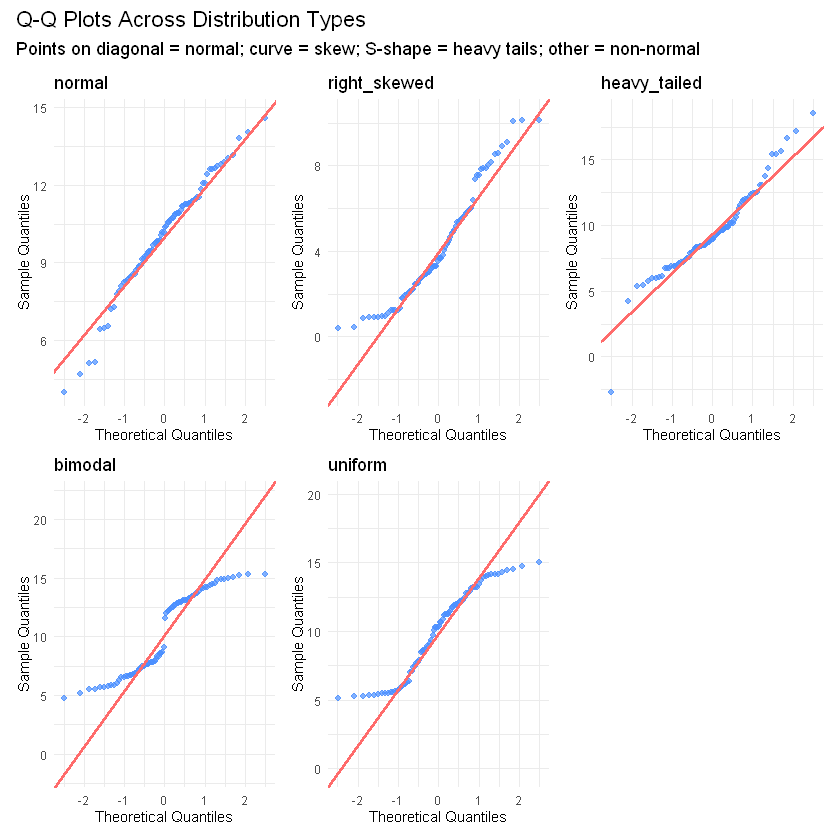

In [3]:
# ── Q-Q plots for all five distributions ─────────────────────────────────────
qq_plots <- map(names(distributions), function(nm) {
  df <- tibble(value = distributions[[nm]])
  ggplot(df, aes(sample = value)) +
    stat_qq(color = "#4a8fff", alpha = 0.7, size = 1.5) +
    stat_qq_line(color = "#ff6b6b", linewidth = 0.9) +
    labs(title = nm,
         x = "Theoretical Quantiles",
         y = "Sample Quantiles") +
    theme_minimal(base_size = 9)
})

patchwork::wrap_plots(qq_plots, ncol = 3) +
  patchwork::plot_annotation(
    title    = "Q-Q Plots Across Distribution Types",
    subtitle = "Points on diagonal = normal; curve = skew; S-shape = heavy tails; other = non-normal"
  )

# ── Q-Q pattern guide ─────────────────────────────────────────────────────────
# On the line:        Normal distribution
# Concave up (right): Right skew — right tail too long
# Concave down:       Left skew — left tail too long
# S-shape (both ends off line): Heavy tails (leptokurtic)
# Inverse S-shape:    Light tails (platykurtic / uniform)
# Step function:      Discrete or rounded data
# Clusters:           Multimodal distribution

---

## Formal Normality Tests

In [4]:
# ── Run all three tests on each distribution ──────────────────────────────────
normality_results <- map_dfr(names(distributions), function(nm) {
  x <- distributions[[nm]]

  sw <- shapiro.test(x)                  # Shapiro-Wilk
  ks <- nortest::lillie.test(x)          # Lilliefors (KS with estimated params)
  ad <- nortest::ad.test(x)              # Anderson-Darling

  tibble(
    distribution = nm,
    SW_W = round(sw$statistic, 4),
    SW_p = round(sw$p.value, 4),
    KS_D = round(ks$statistic, 4),
    KS_p = round(ks$p.value, 4),
    AD_A = round(ad$statistic, 4),
    AD_p = round(ad$p.value, 4)
  )
})

print(normality_results)
# p > 0.05: fail to reject normality (consistent with normality)
# p < 0.05: evidence against normality
#
# Expected: normal passes all; others fail at least some tests
# Uniform may pass Shapiro-Wilk at n=80 — illustrates why visual check is essential

# A tibble: 5 × 7
  distribution  SW_W   SW_p   KS_D   KS_p  AD_A   AD_p
  <chr>        <dbl>  <dbl>  <dbl>  <dbl> <dbl>  <dbl>
1 normal       0.977 0.149  0.0693 0.449  0.516 0.186 
2 right_skewed 0.938 0.0008 0.119  0.0069 1.44  0.0009
3 heavy_tailed 0.945 0.0018 0.11   0.018  1.23  0.003 
4 bimodal      0.874 0      0.177  0      4.20  0     
5 uniform      0.924 0.0002 0.112  0.0145 1.74  0.0002


---

## The Sample Size Problem

Normality tests have two opposite failure modes depending on sample size.

In [5]:
# ── Small n: low power — misses real non-normality ───────────────────────────
# Even a clearly skewed distribution may not be detected with n=10
map_dbl(c(10, 20, 50, 100, 500, 1000), function(n) {
  x <- rgamma(n, shape = 1.5, rate = 0.3)  # clearly right-skewed
  shapiro.test(x[1:min(n, 5000)])$p.value  # SW limited to n<=5000
}) %>%
  setNames(c("n=10", "n=20", "n=50", "n=100", "n=500", "n=1000")) %>%
  round(4) %>%
  print()
# p decreases as n increases — same non-normal distribution, different verdict

# ── Large n: trivially rejects normality for any deviation ───────────────────
# Tiny, practically irrelevant deviation from normality
map_dbl(c(30, 100, 500, 2000), function(n) {
  x <- rnorm(n) + 0.0001 * rnorm(n)^3  # essentially normal
  shapiro.test(x[1:min(n, 5000)])$p.value
}) %>%
  setNames(c("n=30", "n=100", "n=500", "n=2000")) %>%
  round(4) %>%
  print()

cat("\nConclusion: formal tests alone should never determine analytical strategy.\n")
cat("Use Q-Q plots as primary assessment; tests as supplementary evidence.\n")

  n=10   n=20   n=50  n=100  n=500 n=1000 
0.2381 0.0335 0.0000 0.0000 0.0000 0.0000 
  n=30  n=100  n=500 n=2000 
0.0266 0.6264 0.9073 0.3087 

Conclusion: formal tests alone should never determine analytical strategy.
Use Q-Q plots as primary assessment; tests as supplementary evidence.


---

## Testing Normality of Model Residuals

For regression and ANOVA, it is the **residuals** that need to be approximately normal — not the raw data. This is the most common application of normality tests in practice.

`geom_smooth()` using formula = 'y ~ x'


Shapiro-Wilk: W = 0.9854, p = 0.6896
Anderson-Darling: A = 0.2757, p = 0.6466


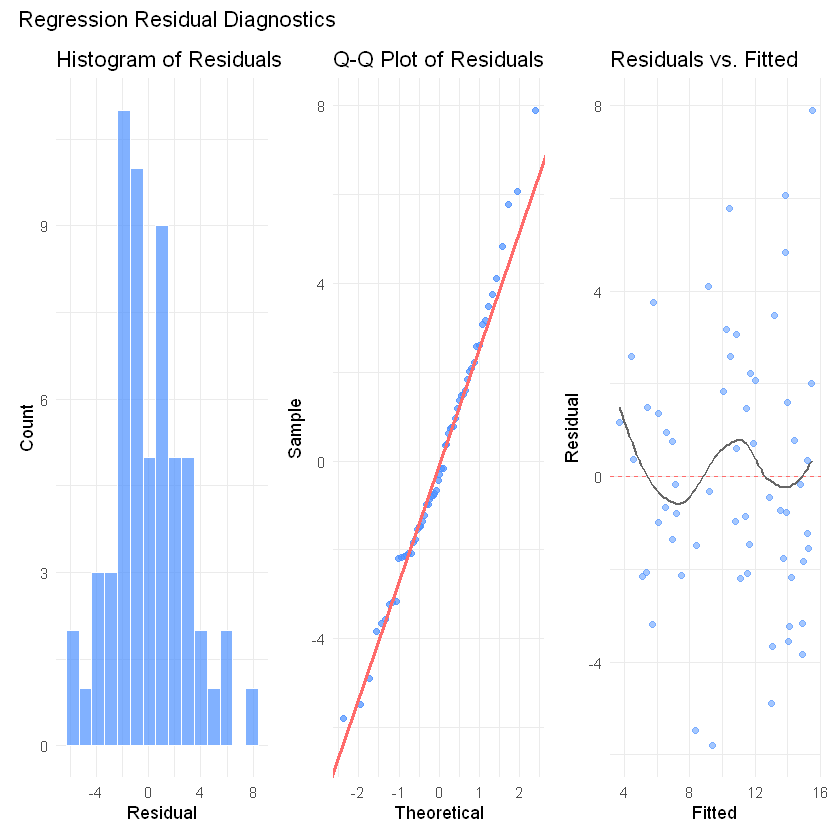

In [6]:
# ── Fit a linear model and check residuals ────────────────────────────────────
n_reg <- 60
reg_data <- tibble(
  x = runif(n_reg, 0, 10),
  y = 2 + 1.5 * x + rnorm(n_reg, 0, 3)
)

lm_fit <- lm(y ~ x, data = reg_data)
resid  <- residuals(lm_fit)

# ── Four-panel residual diagnostic ───────────────────────────────────────────
p1 <- ggplot(tibble(resid = resid), aes(x = resid)) +
  geom_histogram(bins = 15, fill = "#4a8fff", alpha = 0.7, color = "white") +
  labs(title = "Histogram of Residuals", x = "Residual", y = "Count") +
  theme_minimal()

p2 <- ggplot(tibble(resid = resid), aes(sample = resid)) +
  stat_qq(color = "#4a8fff", alpha = 0.7) +
  stat_qq_line(color = "#ff6b6b", linewidth = 0.9) +
  labs(title = "Q-Q Plot of Residuals",
       x = "Theoretical", y = "Sample") +
  theme_minimal()

p3 <- ggplot(tibble(fitted = fitted(lm_fit), resid = resid),
             aes(x = fitted, y = resid)) +
  geom_point(alpha = 0.5, color = "#4a8fff") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "#ff6b6b") +
  geom_smooth(method = "loess", se = FALSE, color = "gray40", linewidth = 0.7) +
  labs(title = "Residuals vs. Fitted", x = "Fitted", y = "Residual") +
  theme_minimal()

(p1 | p2 | p3) +
  patchwork::plot_annotation(
    title = "Regression Residual Diagnostics"
  )

# ── Formal test on residuals ──────────────────────────────────────────────────
sw_resid <- shapiro.test(resid)
ad_resid <- nortest::ad.test(resid)
cat(sprintf("Shapiro-Wilk: W = %.4f, p = %.4f\n", sw_resid$statistic, sw_resid$p.value))
cat(sprintf("Anderson-Darling: A = %.4f, p = %.4f\n", ad_resid$statistic, ad_resid$p.value))

---

## Decision Framework

         raw          log         sqrt 
"p = 0.0031" "p = 0.0007" "p = 0.5486" 


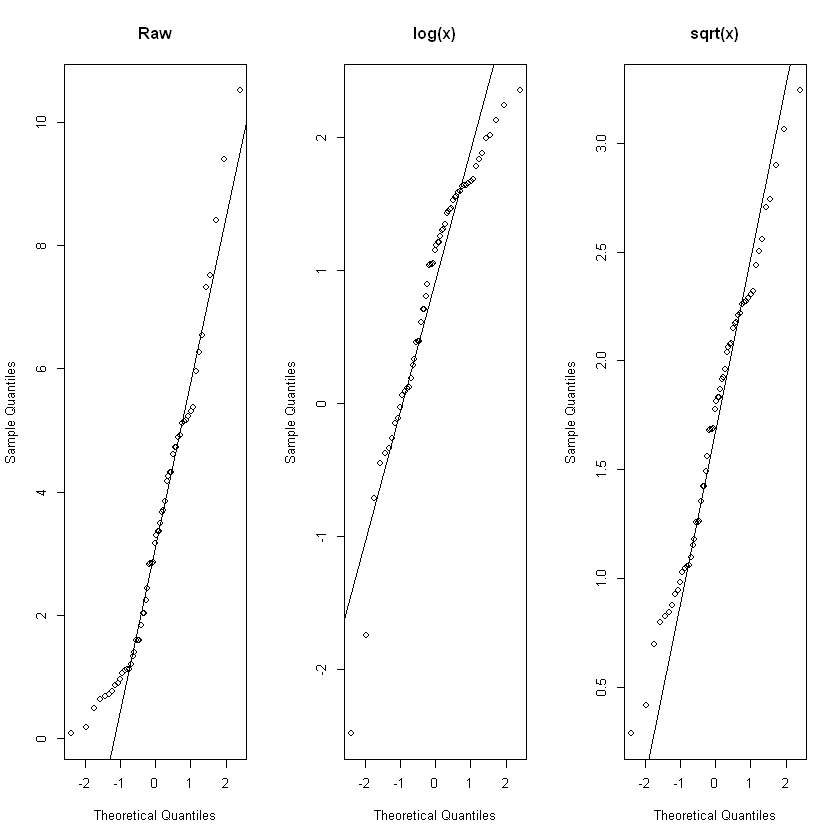

In [7]:
# ── Practical decision guide ──────────────────────────────────────────────────
# Q-Q plot roughly linear AND histogram approximately bell-shaped?
#   YES → Proceed with parametric test
#   NO  → How large is n?
#           n >= 30-50: CLT applies; parametric tests are usually robust
#             → Check if outliers or extreme skew are driving the issue
#             → Consider transformation (log, sqrt) if strongly skewed
#             → Proceed with parametric test if residuals are the concern
#           n < 30: real concern
#             → Try log or sqrt transformation and recheck Q-Q plot
#             → If transformation helps: use transformed data with parametric test
#             → If not: use nonparametric test (Wilcoxon, Kruskal-Wallis)
#             → If testing residuals from a model: report and acknowledge

# ── Common transformations to improve normality ───────────────────────────────
x_raw  <- rgamma(60, shape = 1.5, rate = 0.4)  # right-skewed

par(mfrow = c(1, 3))
qqnorm(x_raw,         main = "Raw");       qqline(x_raw)
qqnorm(log(x_raw),    main = "log(x)");    qqline(log(x_raw))
qqnorm(sqrt(x_raw),   main = "sqrt(x)");   qqline(sqrt(x_raw))
par(mfrow = c(1, 1))

map_chr(list(raw=x_raw, log=log(x_raw), sqrt=sqrt(x_raw)), function(x) {
  p <- shapiro.test(x)$p.value
  sprintf("p = %.4f", p)
}) %>% print()

---

## Reporting Results

In [8]:
# Standard reporting format:
# "Normality of model residuals was assessed visually using Q-Q plots
#  and histograms, and confirmed with the Shapiro-Wilk test
#  (W = X.XXX, p = .XXX). Residuals were approximately normally
#  distributed, supporting the use of parametric inference."
#
# If non-normal:
# "Response variables were strongly right-skewed (Shapiro-Wilk: W = X.XXX,
#  p = .XXX). Log-transformation improved normality (W = X.XXX, p = .XXX)
#  and all subsequent analyses used log-transformed values."
#
# If non-parametric test was used:
# "Data were non-normally distributed (Shapiro-Wilk: W = X.XXX, p = .XXX)
#  and the small sample size (n = XX) precluded reliance on the central
#  limit theorem; accordingly, a Wilcoxon rank-sum test was used."
cat("Reporting guidance shown above.\n")

Reporting guidance shown above.


---

## Common Pitfalls

**1. Using normality tests to decide whether to run a parametric test**  
This is the most common misuse. With small n, tests have low power and fail to detect real non-normality. With large n, they reject perfectly adequate data. Decision should be based on Q-Q plot inspection and subject-matter knowledge.

**2. Testing the raw data instead of model residuals**  
For linear models and ANOVA, normality of the raw data is not required — normality of the residuals is. A skewed predictor distribution is fine as long as the residuals are approximately normal.

**3. Treating a non-significant Shapiro-Wilk as proof of normality**  
A non-significant Shapiro-Wilk only means you failed to detect non-normality — not that the data are normal. With small n, this test has almost no power.

**4. Applying Shapiro-Wilk to n > 2000**  
`shapiro.test()` is limited to n ≤ 5000 in R and becomes overly sensitive beyond n ≈ 2000. For large n, use Anderson-Darling or, better, rely entirely on Q-Q plots — at large n, the CLT makes normality largely irrelevant anyway.

**5. Not checking both tails on the Q-Q plot**  
Heavy-tailed distributions produce a characteristic S-shape on Q-Q plots — both ends curve away from the reference line. A quick glance at only the middle of the plot will miss this. Always examine both tails carefully.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*